In [1]:
!pip install kagglehub

In [2]:
import kagglehub

In [3]:
path = kagglehub.dataset_download("jangedoo/utkface-new")
print("Path:", path)

Using Colab cache for faster access to the 'utkface-new' dataset.
Path: /kaggle/input/utkface-new


In [4]:
import os
files = os.listdir(path)
print(files)

['UTKFace', 'utkface_aligned_cropped', 'crop_part1']


In [5]:
dataset_path = path

In [6]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')
%matplotlib inline

import tensorflow as tf
from keras.preprocessing.image import load_img
from keras.models import Sequential, Model
from keras.layers import Dense,Conv2D,Dropout,Flatten,MaxPooling2D,Input

In [7]:
import kagglehub
path = kagglehub.dataset_download("jangedoo/utkface-new")

import os
BASE_DIR = os.path.join(path, "UTKFace/")
print(BASE_DIR)

Using Colab cache for faster access to the 'utkface-new' dataset.
/kaggle/input/utkface-new/UTKFace/


In [8]:
image_paths = []
age_labels = []
gender_labels = []

for filename in tqdm(os.listdir(BASE_DIR)):
  image_path = os.path.join(BASE_DIR, filename)
  temp = filename.split('_')
  age = int(temp[0])
  gender = int(temp[1])
  image_paths.append(image_path)
  age_labels.append(age)
  gender_labels.append(gender)

  0%|          | 0/23708 [00:00<?, ?it/s]

In [16]:
df = pd.DataFrame()
df['image'], df['age'], df['gender'] = image_paths, age_labels, gender_labels
df.head()

,image,age,gender
0,/kaggle/input/utkface-new/UTKFace/26_0_2_20170...,26,0
1,/kaggle/input/utkface-new/UTKFace/22_1_1_20170...,22,1
2,/kaggle/input/utkface-new/UTKFace/21_1_3_20170...,21,1
3,/kaggle/input/utkface-new/UTKFace/28_0_0_20170...,28,0
4,/kaggle/input/utkface-new/UTKFace/17_1_4_20170...,17,1


In [17]:
gender_dict = {0:'Male', 1:'Female'}

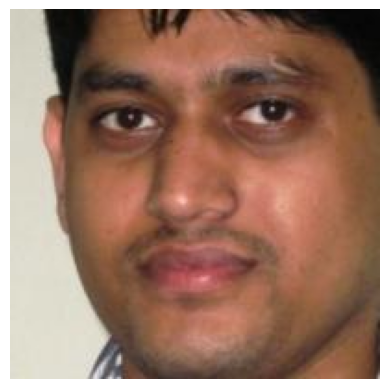

In [18]:
#eda

from PIL import Image
img = Image.open(df['image'][23500])
plt.axis('off')
plt.imshow(img);

<Axes: xlabel='age', ylabel='Density'>

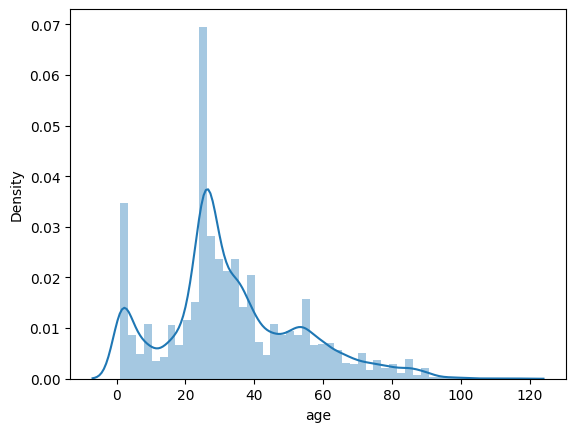

In [19]:
#using distplot via seaborn for age to get rough chart(ye wala right skewed hai kinda)

sns.distplot(df['age'])

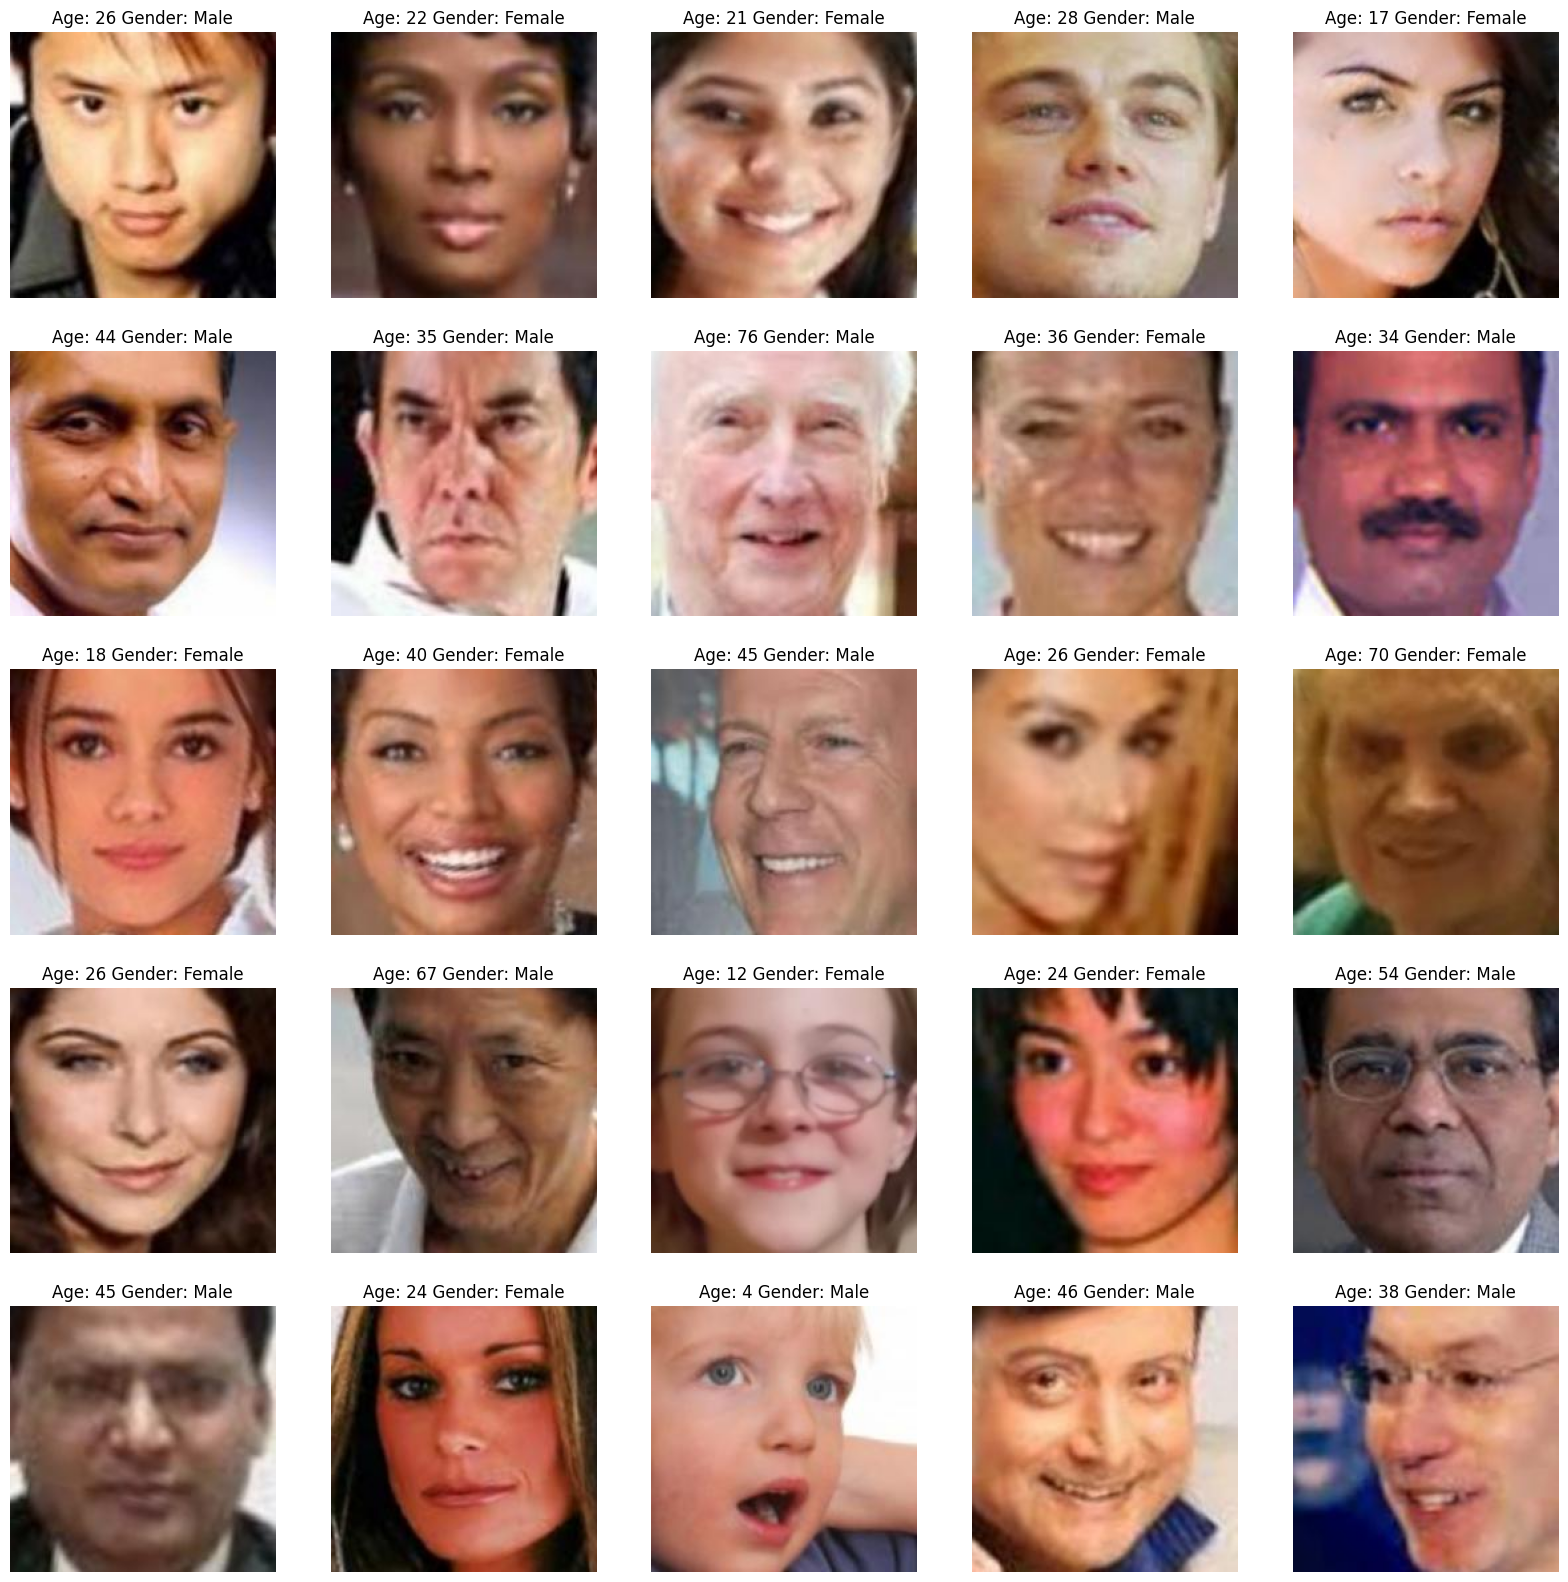

In [20]:
# view all niggus in grid view
plt.figure(figsize=(20,20))
files = df.iloc[0:25]

for index,file,age,gender in files.itertuples():
  plt.subplot(5, 5, index+1)
  img = load_img(file)
  img = np.array(img)
  plt.imshow(img)
  plt.title(f"Age: {age} Gender: {gender_dict[gender]}")
  plt.axis('off')


In [21]:
#feature extraction

def extract_features(images):
  features = []
  for image in tqdm(images):
    img = load_img(image, color_mode='grayscale')
    img = img.resize((128,128), Image.LANCZOS)  #pehle ANTIALIAS tha, now newer keras mein its LANCZOS. niggas just changed name bc
    img = np.array(img)
    features.append(img)

  features = np.array(features)
  features = features.reshape(len(features), 128, 128, 1) #keeping value 1 for grayscale, rgb ke liye 3
  return features

In [15]:
X = extract_features(df['image'])

  0%|          | 0/23708 [00:00<?, ?it/s]

In [22]:
X.shape

(23708, 128, 128, 1)

In [23]:
X = X/255.0 #image normalization

In [24]:
y_gender = np.array(df['gender'])
y_age = np.array(df['age'])

In [25]:
input_shape = (128,128,1)

In [26]:
#model creation - cnn
inputs = Input((input_shape))
#layers:
conv_1 = Conv2D(32, kernel_size=(3,3), activation='relu')(inputs)
maxp_1 = MaxPooling2D(pool_size=(2,2)) (conv_1)
conv_2 = Conv2D(64, kernel_size=(3,3), activation='relu')(maxp_1)
maxp_2 = MaxPooling2D(pool_size=(2,2)) (conv_2)
conv_3 = Conv2D(128, kernel_size=(3,3), activation='relu')(maxp_2)
maxp_3 = MaxPooling2D(pool_size=(2,2)) (conv_3)
conv_4 = Conv2D(256, kernel_size=(3,3), activation='relu')(maxp_3)
maxp_4 = MaxPooling2D(pool_size=(2,2)) (conv_4)

flatten = Flatten() (maxp_4)

#fully connected layers

dense_1 = Dense(256, activation='relu') (flatten)
dense_2 = Dense(256, activation='relu') (flatten)

dropout_1 = Dropout(0.3) (dense_1)
dropout_2 = Dropout(0.3) (dense_2)


output_1 = Dense(1, activation='sigmoid', name='gender_out') (dropout_1)
output_2 = Dense(1, activation='relu', name='age_out') (dropout_2)

model = Model(inputs=[inputs], outputs=[output_1, output_2])

model.compile(loss=['binary_crossentropy', 'mae'], optimizer='adam', metrics=['accuracy', 'mae'])

In [27]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 126, 126,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 63, 63,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 61, 61,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 30, 30,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 12, 12,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 6, 6, 256) │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 9216)      │          0 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  2,359,552 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │  2,359,552 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_out (Dense)  │ (None, 1)         │        257 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_out (Dense)     │ (None, 1)         │        257 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,107,458 (19.48 MB)

 Trainable params: 5,107,458 (19.48 MB)

 Non-trainable params: 0 (0.00 B)

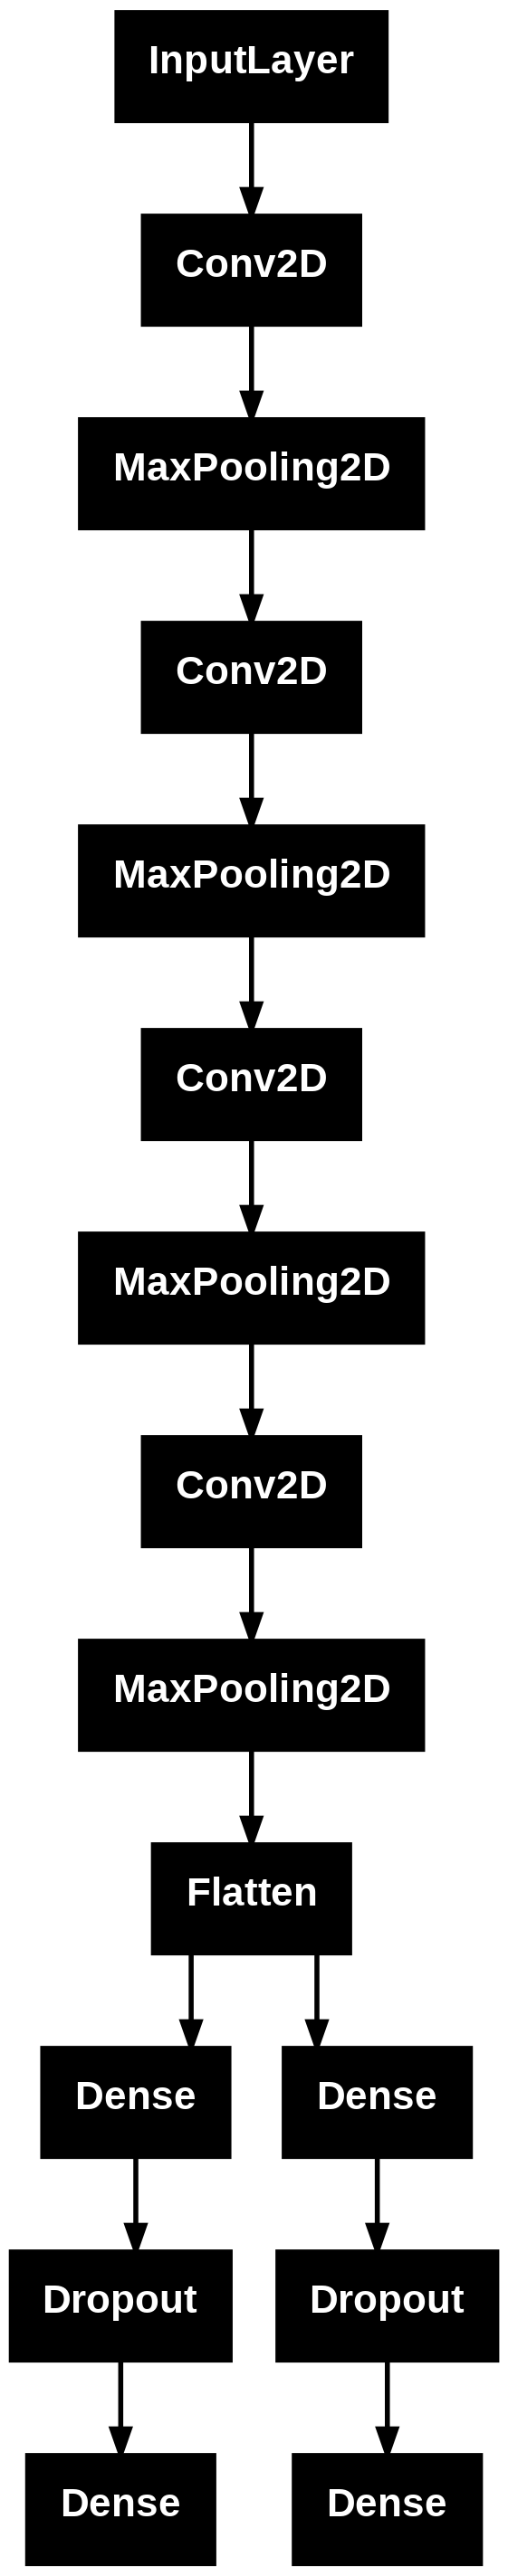

In [28]:
#chart generate hoga using keras ka some shit

from tensorflow.keras.utils import plot_model
plot_model(model)

In [29]:
#model training big shit

history = model.fit(x=X, y = [y_gender, y_age], batch_size=32, epochs=15, validation_split=0.2)

Epoch 1/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 480s 806ms/step - age_out_loss: 15.0680 - age_out_mae: 15.0689 - gender_out_accuracy: 0.5960 - gender_out_loss: 0.6563 - loss: 15.7253 - val_age_out_loss: 11.8284 - val_age_out_mae: 11.8144 - val_gender_out_accuracy: 0.7341 - val_gender_out_loss: 0.5294 - val_loss: 12.3419
Epoch 2/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 485s 818ms/step - age_out_loss: 11.1044 - age_out_mae: 11.1039 - gender_out_accuracy: 0.7641 - gender_out_loss: 0.4856 - loss: 11.5896 - val_age_out_loss: 9.8451 - val_age_out_mae: 9.8502 - val_gender_out_accuracy: 0.8005 - val_gender_out_loss: 0.4376 - val_loss: 10.2871
Epoch 3/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 500s 843ms/step - age_out_loss: 9.2997 - age_out_mae: 9.2998 - gender_out_accuracy: 0.8103 - gender_out_loss: 0.4036 - loss: 9.7034 - val_age_out_loss: 9.2672 - val_age_out_mae: 9.2862 - val_gender_out_accuracy: 0.8178 - val_gender_out_loss: 0.3765 - val_loss: 9.6613
Epoch 4/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 494s 829ms/step - age_out_

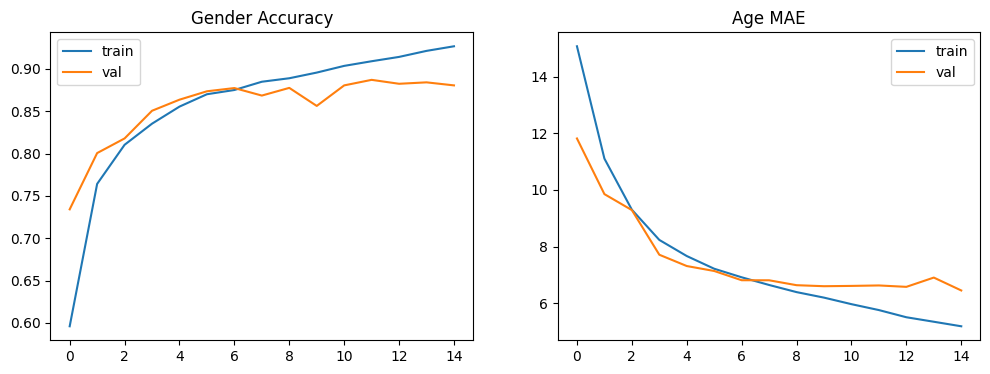

In [30]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['gender_out_accuracy'], label='train')
plt.plot(history.history['val_gender_out_accuracy'], label='val')
plt.title('Gender Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['age_out_mae'], label='train')
plt.plot(history.history['val_age_out_mae'], label='val')
plt.title('Age MAE')
plt.legend()

Original Gender: Female Original Age: 24
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
Predicted Gender: Female Predicted Age: 25


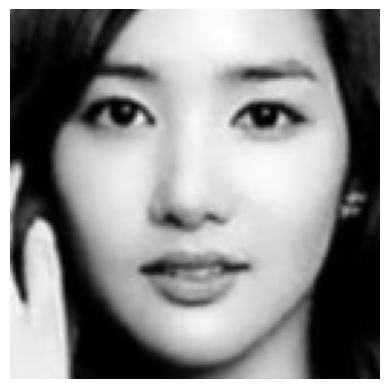

In [31]:
#prediction time babyyyyy
image_index = 3483
print("Original Gender:", gender_dict[y_gender[image_index]], "Original Age:", y_age[image_index])


pred = model.predict(X[image_index].reshape(1, 128, 128, 1))

pred_gender = gender_dict[round(pred[0][0][0])]
pred_age = round(pred[1][0][0])

print("Predicted Gender:", pred_gender, "Predicted Age:", pred_age)

plt.axis('off')
plt.imshow(X[image_index].reshape(128, 128), cmap='gray');

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/training_curves.png'

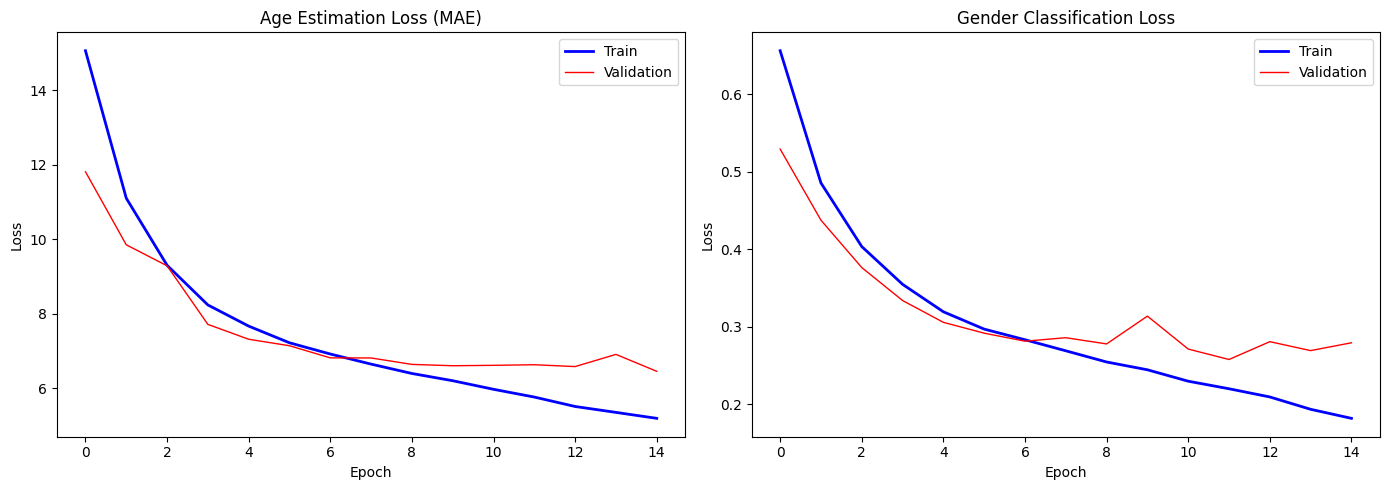

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Graph 1: Age Loss (MAE) ---
axes[0].plot(history.history['age_out_mae'],
             color='blue', label='Train', linewidth=2)
axes[0].plot(history.history['val_age_out_mae'],
             color='red', label='Validation', linewidth=1)
axes[0].set_title('Age Estimation Loss (MAE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# --- Graph 2: Gender Loss ---
axes[1].plot(history.history['gender_out_loss'],
             color='blue', label='Train', linewidth=2)
axes[1].plot(history.history['val_gender_out_loss'],
             color='red', label='Validation', linewidth=1)
axes[1].set_title('Gender Classification Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_curves.png')  # saves to Drive
plt.show()

In [34]:
from scipy.ndimage import uniform_filter1d
import numpy as np

def smooth(values, weight=0.6):
    smoothed = []
    last = values[0]
    for v in values:
        smoothed_val = last * weight + (1 - weight) * v
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

# Then plot like this:
age_train = history.history['age_out_mae']
axes[0].plot(smooth(age_train), color='blue',
             label='Train (smoothed)', linewidth=2)
axes[0].plot(age_train, color='red',
             alpha=0.4, label='Train (actual)', linewidth=1)